In [1]:
gen_report = False

In [2]:
import os
import json
import pandas as pd

root = "experiments"

records = []

for dirpath, dirnames, filenames in os.walk(root):
    if "report.json" in filenames:
        report_path = os.path.join(dirpath, "report.json")

        with open(report_path, "r") as f:
            data = json.load(f)

        record = {}

        record["VQEL"] = data.get("VQEL")

        # metrics
        for k, v in data.get("metrics", {}).items():
            record[k] = v

        # config
        for k, v in data.get("config", {}).items():
            if 'dir' in k.lower() or 'split' in k.lower():
                continue
            record[k] = v

        record["path"] = dirpath.replace('experiments/', '').replace('/results', '')
        records.append(record)

df = pd.DataFrame(records)
# df.to_csv('VQTT_results.csv', index=False)
# df = pd.read_csv('VQTT_results.csv')
# df.to_pickle('VQTT_results.pkl')
# df = pd.read_pickle('VQTT_results.pkl')

df["reset_unfrozen_params"] = df["reset_unfrozen_params"].map({True: "yes", False: "no"})
df["freeze_codebook"] = df["freeze_codebook"].map({True: "yes", False: "no"})
df["freeze_object_encoder"] = df["freeze_object_encoder"].map({True: "yes", False: "no"})

df.loc[df["num_iterations"] == 0, "learning_rate_tt"] = "-"
df.loc[df["agent_a_training_mode"] == 'frozen', "learning_rate_phase2_a"] = "-"
df.loc[df["best_of_n"].isna(), "best_of_n"] = 1
df.loc[df["dataset_tt"].isna(), "dataset_tt"] = "one_shape"
df.loc[df["sampling_temperature_tt"].isna(), "sampling_temperature_tt"] = df["sampling_temperature"]
df.loc[df["gumbel"].isna(), "gumbel"] = False

df.loc[(df["num_iterations"] == 0) | (df["best_of_n"] == 1), "test_time_mode"] = "-"

df.rename(columns={"test_time_training_accuracy": "test_time_mutual_accuracy"}, inplace=True)
df.rename(columns={"test_time_self_play_accuracy": "test_time_self_accuracy"}, inplace=True)

df["test_time_mode"] = df["test_time_mode"].replace("adaptation", "sample_adaptation")
df["dataset"] = df["dataset"].replace("shape", "shape1")
df["dataset_tt"] = df["dataset_tt"].replace("two_shape", "shape2")
df["dataset_tt"] = df["dataset_tt"].replace("shape_unique_double_attribute", "dual_attribute_shape")
# df["dataset_tt"] = df["dataset_tt"].replace("shape_unique_double_attribute", "single_attribute_shape")

df.loc[df["baseline"].isna(), "baseline"] = False

df.loc[df["baseline"], "test_time_mode"] = "-"

df["test_time_mutual_accuracy"] = df["test_time_mutual_accuracy"] * 100
df["test_time_self_accuracy"] = df["test_time_self_accuracy"] * 100
df["mutual_play_accuracy"] = df["mutual_play_accuracy"] * 100
df["self_play_accuracy_a"] = df["self_play_accuracy_a"] * 100

df = df.where(pd.notna(df), "None")
pd.options.display.float_format = '{:.10g}'.format
df = df.map(lambda x: f"{x:.0e}" if isinstance(x, (int, float)) and x != 0 and (abs(x) < 0.01 or abs(x) == 0.1 or abs(x) == 0.01) else x)
print("Total reports loaded:", len(df))

pd.set_option('display.max_rows', None)

Total reports loaded: 8025


/tmp/ipykernel_288940/3750467460.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["num_iterations"] == 0, "learning_rate_tt"] = "-"
/tmp/ipykernel_288940/3750467460.py:44: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["agent_a_training_mode"] == 'frozen', "learning_rate_phase2_a"] = "-"


In [3]:
def filter_df(filters, df=df, sort_by=["message_length", "message_length_tt", "learning_rate_tt", "num_iterations"]):

    idx = pd.Series(True, index=df.index)

    for key, values in filters.items():
        mask = pd.Series(False, index=df.index)
        if not isinstance(values, (list, tuple, set)):
            values = [values]
        for value in values:
            if (type(value) == str) and value.startswith('>'):
                mask |= (df[key] > value.split('>')[1])
            if value == "!None":
                mask |= (df[key] != "None")
            else:
                mask |= (df[key] == value)
        idx &= mask 

    return df[idx].sort_values(by=sort_by).reset_index(drop=True)

    

In [4]:
import base64

def to_html(df):    

    # ---- highlight rule ----
    # if 'mutual_play_accuracy' in df:
    #     max_col = 'mutual_play_accuracy'
    # else:
    #     max_col = 'test_accuracy'
    # max_val = pd.to_numeric(df[max_col]).max()

    # def highlight_max_row(row):
    #     if  pd.to_numeric(row[max_col]) == max_val:
    #         return ['font-weight: bold; background-color: #ffff99'] * len(row)
    #     else:
    #         return [''] * len(row)

    # ---- style ----
    styled = (
        df.style
            # .apply(highlight_max_row, axis=1)  # <<< APPLY HIGHLIGHT HERE
            .hide(axis="index")
            .format(
                lambda x: (
                    f"{int(x)}"                      # 20.0 -> 20
                    if isinstance(x, float) and x.is_integer()
                    else f"{x:.0e}"                  # small numbers -> scientific
                    if isinstance(x, (int, float)) and x != 0 and abs(x) < 0.01
                    else x
                )
            )
            .set_table_styles([
                {"selector": "td", "props": [("border-right", "1px solid black")]},
                {"selector": "th", "props": [
                    ("border-right", "1px solid black"),
                    ("color", "darkblue"),
                    ("font-weight", "bold"),
                    ("padding-left", "8px"),
                    ("padding-right", "8px")
                ]},
            ])
            .set_properties(**{"text-align": "center"})
    )

    html_table = styled.to_html(index=False)

    if gen_report:
        with open("results.html", "a") as f:
            f.write(html_table)

        
def add_heading(num=1, title=""):
    """Add a professional-colored heading to results.html"""
    colors = ["#0b3d91",  # dark blue
              "#800000",  # maroon
              "#205522",  # dark green
              "#111011",  # indigo
              "#444444"]  # dark gray
    color = colors[(num-1) % len(colors)]  # cycle through colors
    
    if gen_report:
        with open("results.html", "a") as f:
            f.write(f'<h{num} style="color:{color}; font-family:Arial, sans-serif;">{title}</h{num}>\n')
        
def clear():
    if gen_report:
        with open("results.html", "w") as f:
            f.write("")

def line():
    if gen_report:
        with open("results.html", "a") as f:
            f.write('<hr style="border:1px solid #444; margin:10px 0;">\n')
        
        
def write(text):
    html_text = text.replace("\n", "<br>\n")
    
    if gen_report:
        with open("results.html", "a") as f:
            f.write(f"{html_text}\n")


def add_plot(path="plot.png"):
    """Embed an image file directly into results.html using base64."""
    with open(path, "rb") as img:
        encoded = base64.b64encode(img.read()).decode("utf-8")

    html_img = (
        '<img src="data:image/png;base64,' +
        encoded +
        '" style="max-width:650px; height:auto;"><br>\n'
    )

    if gen_report:
        with open("results.html", "a") as f:
            f.write(html_img)
        
    if os.path.exists(path):
        os.remove(path)

In [5]:
import os
import shutil

def remove_expr(res_df):
    for path in res_df["path"]:
        full_path = os.path.join("experiments", path)

        if not os.path.isdir(full_path):
            print(f"[SKIP] Not found: {full_path}")
            continue

        answer = input(f"⚠️ Delete expr '{path}' ? (y/n): ").strip().lower()

        if answer == "y":
            shutil.rmtree(full_path)
            print(f"✅ Deleted: {path}")
        else:
            print(f"❌ Skipped: {path}")

In [6]:
metrics = []

In [7]:
import numpy as np
import pandas as pd
from itertools import product


def _find_elbow_idx(x, y):
    if len(x) <= 2:
        return np.argmax(y)

    x = np.asarray(x)
    y = np.asarray(y)

    x1, y1 = x[0], y[0]
    x2, y2 = x[-1], y[-1]

    numerator = np.abs(
        (x2 - x1) * (y1 - y) -
        (y2 - y1) * (x1 - x)
    )

    denominator = np.hypot(x2 - x1, y2 - y1)

    distances = numerator / denominator

    return np.argmax(distances)
    

def extract_maxes_elbow(
    df,
    cols=["message_length", "message_length_tt", "seed"],
    max_col="test_time_self_accuracy",
):
    values = []

    for col in cols:
        values.append(set(df[col]))

    combinations = [list(x) for x in product(*values)]

    maxes = []

    for comb in combinations:

        section = filter_df(
            {col: value for col, value in zip(cols, comb)},
            df,
        )

        if section.empty:
            continue

        # ======================================================
        # Split this section by learning rate
        # ======================================================

        elbow_rows = []

        for lr, lr_section in section.groupby("learning_rate_tt"):

            lr_section = lr_section.copy()

            lr_section["num_iterations"] = pd.to_numeric(
                lr_section["num_iterations"]
            )

            lr_section[max_col] = pd.to_numeric(
                lr_section[max_col]
            )

            lr_section = lr_section.sort_values(
                "num_iterations"
            )

            x = lr_section["num_iterations"].values
            y = lr_section[max_col].values

            elbow_idx = _find_elbow_idx(x, y)

            elbow_row = lr_section.iloc[elbow_idx]

            elbow_rows.append(elbow_row)

            # ==================================================
            # DEBUG INFO
            # Uncomment to verify the elbow selection
            # ==================================================
            #
            # print(
            #     f"\nCombination={comb}"
            # )
            # print(
            #     f"LR={lr}"
            # )
            # print(
            #     lr_section[
            #         ["num_iterations", max_col]
            #     ]
            # )
            # print(
            #     f"Elbow iteration={elbow_row['num_iterations']}"
            # )
            # print(
            #     f"Elbow accuracy={elbow_row[max_col]:.4f}"
            # )
            #
            # ==================================================

        if len(elbow_rows) == 0:
            continue

        elbow_df = pd.DataFrame(elbow_rows)

        # ======================================================
        # Among all learning rates, keep the elbow row with the
        # highest accuracy
        # ======================================================

        best_elbow_row = elbow_df.loc[
            elbow_df[max_col].idxmax()
        ]

        # ======================================================
        # DEBUG INFO
        # Uncomment to verify the final choice
        # ======================================================
        #
        # print(
        #     "\nSelected LR:",
        #     best_elbow_row["learning_rate_tt"]
        # )
        # print(
        #     "Selected Iter:",
        #     best_elbow_row["num_iterations"]
        # )
        # print(
        #     "Selected Acc:",
        #     best_elbow_row[max_col]
        # )
        #
        # ======================================================

        maxes.append(best_elbow_row.to_frame().T)

    final_df = pd.concat(maxes, ignore_index=True)

    return (
        final_df
        .sort_values(by=cols)
        .reset_index(drop=True)
    )

In [8]:
def extract_maxes(df, cols=["message_length", "message_length_tt", "seed"], max_col="test_time_mutual_accuracy"):
    values = []
    for col in cols:
        value = set(df[col])
        values.append(value)

    combinations = [list(x) for x in product(*values)]

    maxes = []
    for comb in combinations:
        section = filter_df({col: value for col, value in zip(cols, comb)}, df)
        if not section.empty:
            max_row = section.loc[pd.to_numeric(section[max_col]).idxmax()]
            maxes.append(max_row.to_frame().T)

    final_df = pd.concat(maxes, ignore_index=True)
    return final_df.sort_values(by=cols).reset_index(drop=True)

In [9]:
def find_best_length_elbow(df):
    x = df["message_length_tt"].to_numpy()

    y = (
        df["test_time_self_accuracy"]
        .str.extract(r"([\d.]+)")
        .astype(float)
        .squeeze()
        .to_numpy()
    )
    
    print(x)
    print(y)
    idx = _find_elbow_idx(x, y)
    return x[_find_elbow_idx(x, y)], df.loc[idx, "test_time_mutual_accuracy"]


In [10]:
from itertools import product
import pandas as pd


def mean_and_std(df, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode"], metrics=["test_time_self_accuracy", "test_time_mutual_accuracy"] + metrics, precision=1):
    rows = []

    for i in range(0, len(df), 3):
        chunk = df.iloc[i:i+3]
        
        rows.append(
            {col: chunk[col].iloc[0] for col in config_cols} | 
            # {metric: f"{pd.to_numeric(chunk[metric]).mean() * 100:.1f} ± {pd.to_numeric(chunk[metric]).std() * 100:.1f}" for metric in metrics}
            {
            metric: (
                None
                if pd.to_numeric(chunk[metric], errors="coerce").dropna().empty
                else f"{pd.to_numeric(chunk[metric], errors='coerce').mean():.{precision}f} ± "
                     f"{pd.to_numeric(chunk[metric], errors='coerce').std():.{precision}f}"
            )
            for metric in metrics
        }
        )

    out = pd.DataFrame(rows)
    return out.sort_values(by=config_cols)
    

In [11]:
def smooth(values, factor=0.5):
    """Exponential moving average smoothing."""
    smoothed = []
    s = values[0]
    for v in values:
        s = factor * s + (1 - factor) * v
        smoothed.append(s)
    return smoothed

In [12]:
import matplotlib.pyplot as plt

METHOD_COLORS = {
    "GS-ST": "#8c2d04",
    "REINFORCE": "#1f77b4",
    "VQEL": "#ff7f0e",
    "VQEL + TTA (Batch)": "#2ca02c",
    "VQEL + TTA (Dataset)": "#9467bd",
    "VQEL + TTA (Full)": "#7f7f7f",
    "VQEL + TTA (MG)": "#2ca02c",
    "Scaling": "#7f7f7f",
    "LR = 1e-4": "#8c2d04",
    "LR = 1e-5": "#7f7f7f",
    "LR = 1e-6": "#2ca02c",
}


def plot(
    dfs,
    labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "VQEL + TTA (Dataset)", "Scaling"),
    name="name",
    xcol="message_length_tt",
    xlabel="Message Length",
    marker="o",
    smooth_factor=0,
    xticks=None,
    logscale=False,
    base=10,
    grid=True
    ):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

    all_x = []

    for df, label in zip(dfs, labels):
        if label not in METHOD_COLORS:
            raise ValueError(f"No color defined for label: {label}")

        color = METHOD_COLORS[label]

        df = df.copy()

        # Split "mean ± std"
        df[["mean_acc", "std_acc"]] = (
            df["test_time_mutual_accuracy"]
            .str.split("±", expand=True)
            .astype(float)
        )

        df = df.sort_values(xcol)

        x = df[xcol]
        y = df["mean_acc"]
        err = df["std_acc"]

        all_x.extend(x.tolist())

        ax.plot(
            x,
            smooth(y, factor=smooth_factor),
            marker=marker,
            linewidth=2,
            color=color,
            label=label,
        )

        ax.fill_between(
            x,
            smooth(y - err, factor=smooth_factor),
            smooth(y + err, factor=smooth_factor),
            color=color,
            alpha=0.2,
            linewidth=0,
        )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Accuracy on OOD Split (\%)", fontsize=12)

    if xticks == None:
        xticks = sorted(set(all_x))
    ax.set_xticks(xticks)
    
    ax.tick_params(axis="both", labelsize=10)

    ax.legend(frameon=False)
    if grid:
        ax.grid(alpha=0.3)
    
    if logscale:
        ax.set_xscale('log', base=base)
    fig.tight_layout()

    plt.savefig(
        f"assets/{name}.pdf",
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()
    

In [13]:
clear()

---

In [14]:

gumbel_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "learning_rate_phase2_a", 
    "learning_rate_phase2_b",
    "tau_0",
    "mutual_play_accuracy",
    "sampling_temperature",
    "test_time_mode",
    "path",
]

backbone_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "learning_rate_phase1", 
    "learning_rate_phase2_a", 
    "learning_rate_phase2_b",
    "test_time_mode",
    "self_play_accuracy_a",
    "mutual_play_accuracy",
    "path",
]

backbone_cols_report = [
    "seed",
    "message_length",
    "agent_a_training_mode",
    "self_play_accuracy_a",
    "mutual_play_accuracy",
]

baseline_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
] + metrics + [
    "path",
]

baseline_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

scaling_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "sampling_temperature_tt",
    "best_of_n",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

scaling_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "sampling_temperature_tt",
    "best_of_n",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

adapt_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

adapt_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

In [15]:
write(
"""
- <b>Shape1</b>: Contains only one shape.

- <b>Shape2</b>: Contains exactly two shapes.

- <b>Shape12</b>: Contains one or two shapes.

- <b>MNIST1</b>: Contains one digit on either the left or right side of the image (the other side is empty).

- <b>MNIST2</b>: Contains two digits.

- <b>ImageNet_same_class</b>: Distractors and targets belong to the same class.

- <b>Single Attribute Shape</b>: Candidates in a batch have two attributes; the value of one attribute is different for all images,
while there is no restriction on the value of the other attribute—it may be the same for some images and different for others.

- <b>Dual-attribute shape</b>: Candidates in a batch have two attributes, and all candidates can be distinguished from one another 
if and only if the values of both attributes are described.
"""
)

# Shape

## Gumbel - ID

In [16]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "None",
    "baseline": True,
    "gumbel": True
}, sort_by=["seed"])
# res[gumbel_cols]

In [17]:
final = extract_maxes(res, max_col="mutual_play_accuracy")
# final[gumbel_cols]

In [18]:
mean = mean_and_std(final, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,shape1,"[3, 4]",84.2 ± 0.8


## Gumbel - OOD

In [19]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "!None",
    "baseline": True,
    "gumbel": True,
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [20]:
gumbel = mean_and_std(res, metrics=["test_time_self_accuracy", "test_time_mutual_accuracy", "unique_messages"])
# gumbel

## REINFORCE - ID

In [21]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "None",
    "baseline": True,
    "gumbel": False
}, sort_by=["seed"])
# res[backbone_cols]

In [22]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,shape1,"[3, 4]",86.5 ± 0.2


## REINFORCE - OOD

In [23]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "!None",
    "baseline": True,
    "gumbel": False
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [24]:
REINFORCE = mean_and_std(res)
# REINFORCE

## VQEL - ID

In [25]:
add_heading(2, "Shape1")
add_heading(3, "Base Model")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": "-",
    "dialogued_checkpoint": "None",
}, sort_by=["message_length"])
res = extract_maxes(res, max_col="mutual_play_accuracy")
res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,False,shape1,cosine,"[3, 4]",1e-03,-,1e-04,-,84.1,88.9,20251220_0615_bs32_vocab10_repr1024_lr1_0.001_...
1,2,False,shape1,cosine,"[3, 4]",1e-03,-,1e-03,-,83.7,88.8,20251228_1437_bs32_vocab10_repr1024_msg_len10_...
2,3,False,shape1,cosine,"[3, 4]",1e-03,-,1e-04,-,84.6,88.5,20251228_2016_bs32_vocab10_repr1024_msg_len10_...


In [26]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,shape1,"[3, 4]",84.1 ± 0.5,88.7 ± 0.2


## VQEL - OOD

In [27]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dataset_tt": "shape2",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": "-"
}, sort_by=["message_length_tt", "seed"])

to_html(res[baseline_cols_report])

# res[baseline_cols]

In [28]:
VQ_NoTT = mean_and_std(res)
VQ_NoTT

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,shape1,"[3, 4]",4,shape2,-,41.2 ± 2.5,47.9 ± 1.1
1,shape1,"[3, 4]",5,shape2,-,43.6 ± 2.2,49.6 ± 2.0
2,shape1,"[3, 4]",6,shape2,-,44.1 ± 2.2,50.1 ± 2.2
3,shape1,"[3, 4]",7,shape2,-,44.1 ± 2.9,48.8 ± 3.5
4,shape1,"[3, 4]",8,shape2,-,43.9 ± 2.5,47.6 ± 4.5
5,shape1,"[3, 4]",9,shape2,-,43.3 ± 2.4,46.7 ± 5.1
6,shape1,"[3, 4]",10,shape2,-,42.7 ± 3.4,44.7 ± 5.5
7,shape1,"[3, 4]",11,shape2,-,42.2 ± 2.9,43.8 ± 6.6
8,shape1,"[3, 4]",12,shape2,-,41.1 ± 3.9,42.6 ± 6.9
9,shape1,"[3, 4]",13,shape2,-,40.2 ± 3.4,40.7 ± 7.3


In [29]:
find_best_length_elbow(VQ_NoTT)

[ 4  5  6  7  8  9 10 11 12 13 14 15]
[41.2 43.6 44.1 44.1 43.9 43.3 42.7 42.2 41.1 40.2 38.9 38.5]


(np.int64(8), '47.6 ± 4.5')

## Scaling

In [30]:
add_heading(3, "Scaling")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": "scaling"
}, sort_by=["message_length", "message_length_tt", "seed", "sampling_temperature_tt", "best_of_n"])

to_html(res[scaling_cols_report])

# res[scaling_cols]

In [31]:
final = extract_maxes(res)
# final[scaling_cols]

In [32]:
scaling = mean_and_std(final)
# scaling

## Batch Adaptation

In [33]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": ["batch_adaptation"],
}, sort_by=["message_length_tt","seed", "learning_rate_tt"])

# res[adapt_cols]

In [34]:
final = extract_maxes_elbow(res)
# final[adapt_cols]

In [35]:
batch_adapt = mean_and_std(final)
batch_adapt

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,shape1,"[3, 4]",4,shape2,batch_adaptation,48.9 ± 2.8,52.3 ± 2.1
1,shape1,"[3, 4]",5,shape2,batch_adaptation,52.7 ± 3.9,54.7 ± 2.2
2,shape1,"[3, 4]",6,shape2,batch_adaptation,54.4 ± 3.9,55.4 ± 2.5
3,shape1,"[3, 4]",7,shape2,batch_adaptation,55.6 ± 4.2,55.9 ± 3.1
4,shape1,"[3, 4]",8,shape2,batch_adaptation,55.3 ± 4.9,55.8 ± 2.6
5,shape1,"[3, 4]",9,shape2,batch_adaptation,55.5 ± 4.4,55.0 ± 3.3
6,shape1,"[3, 4]",10,shape2,batch_adaptation,56.5 ± 3.9,55.3 ± 2.2
7,shape1,"[3, 4]",11,shape2,batch_adaptation,54.8 ± 5.3,54.1 ± 3.9
8,shape1,"[3, 4]",12,shape2,batch_adaptation,57.6 ± 3.7,55.4 ± 2.3
9,shape1,"[3, 4]",13,shape2,batch_adaptation,57.0 ± 3.3,55.2 ± 2.8


In [36]:
find_best_length_elbow(batch_adapt)

[ 4  5  6  7  8  9 10 11 12 13 14 15]
[48.9 52.7 54.4 55.6 55.3 55.5 56.5 54.8 57.6 57.  56.4 57.7]


(np.int64(7), '55.9 ± 3.1')

## Dataset Adaptation

In [37]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": ["dataset_adaptation"],
}, sort_by=["message_length_tt","seed", "learning_rate_tt"])
# res[adapt_cols]

In [38]:
final = extract_maxes_elbow(res)
# final[adapt_cols]

In [39]:
dataset_adapt = mean_and_std(final)
# dataset_adapt

In [40]:
find_best_length_elbow(dataset_adapt)

[ 4  5  6  7  8  9 10 11 12 13 14 15]
[46.  48.1 50.  50.7 51.7 52.2 52.5 52.9 52.8 53.2 53.  52.5]


(np.int64(8), '51.3 ± 2.2')

## Plot

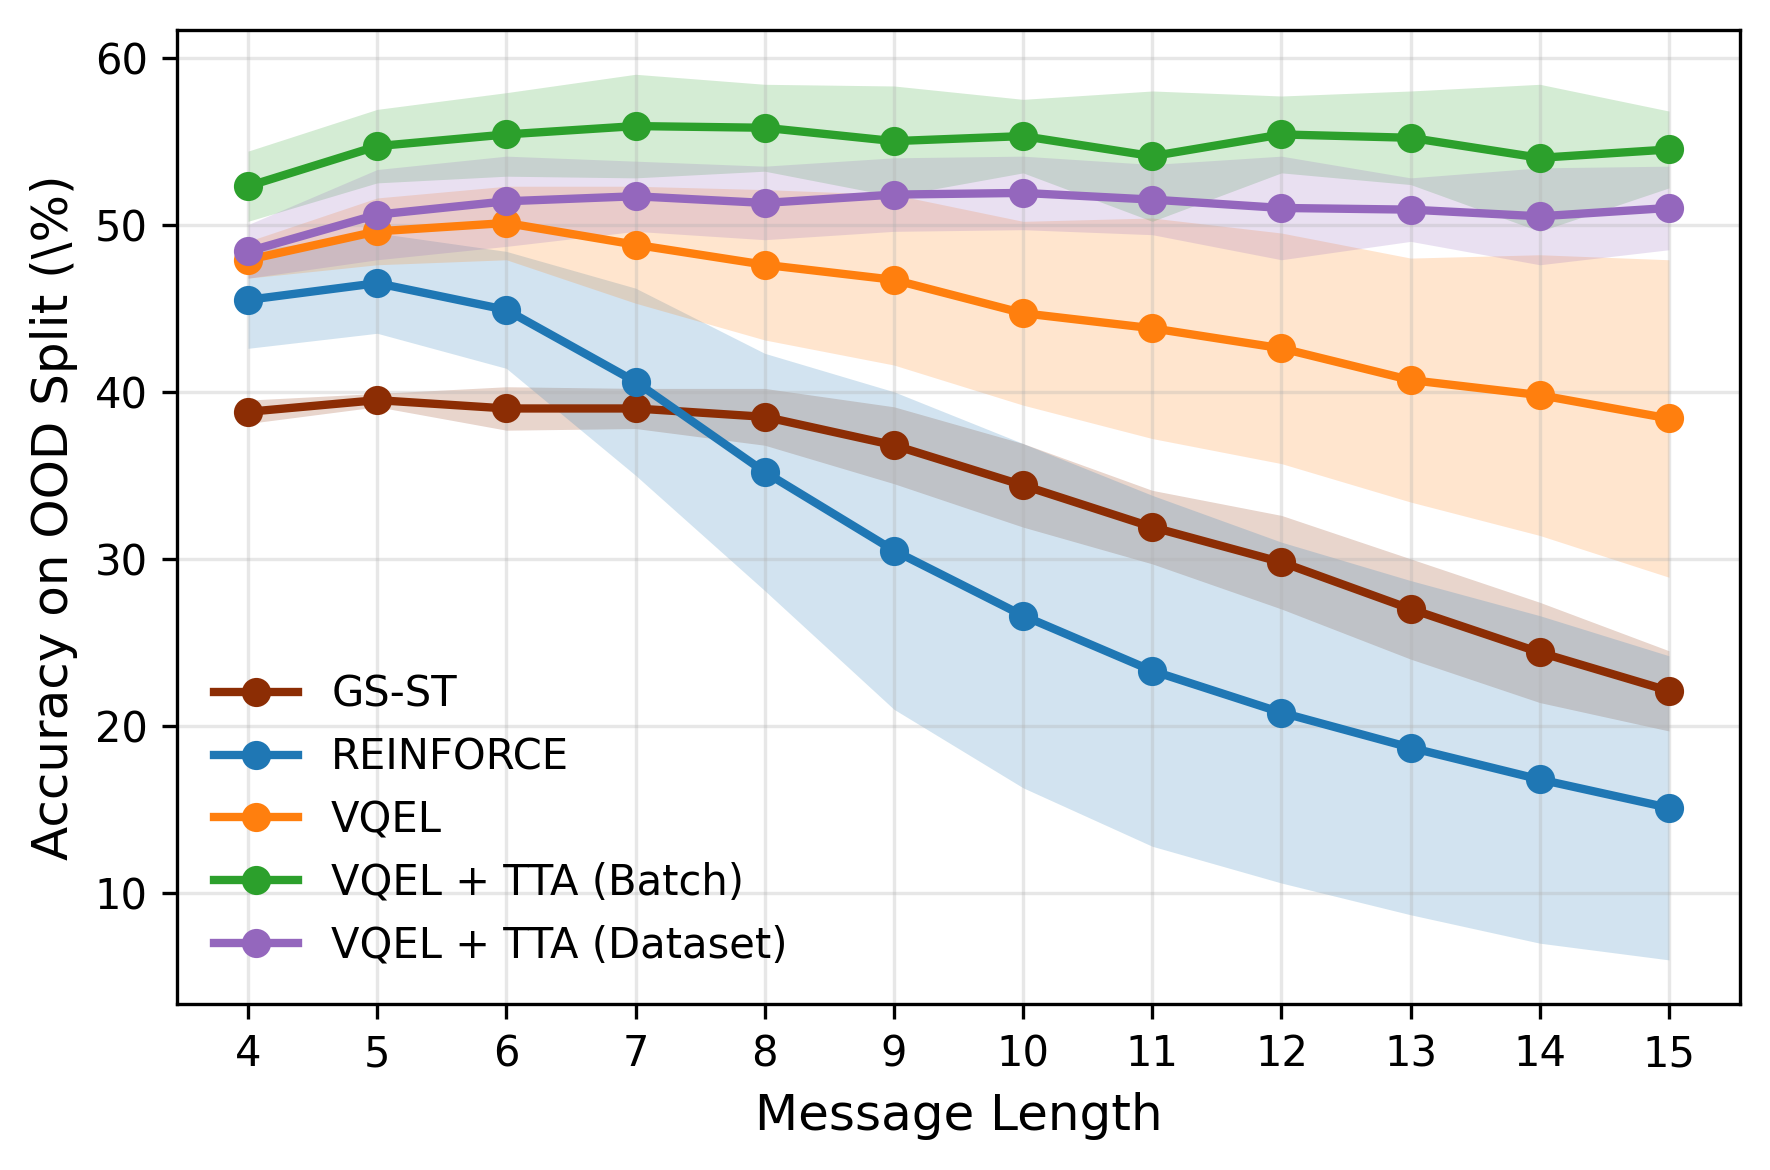

In [41]:
plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, dataset_adapt], name="shape")

In [42]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, scaling], labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "Scaling"),name="shape-scaling")

# MNIST

## Gumbel - ID

In [43]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "None",
    "gumbel": True,
    "number_of_candidates": 100,
    "message_length": "[3, 4]"
}, sort_by=["seed"])

# res[gumbel_cols]

In [44]:
final = extract_maxes(res, max_col="mutual_play_accuracy")
final[gumbel_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase2_a,learning_rate_phase2_b,tau_0,mutual_play_accuracy,sampling_temperature,test_time_mode,path
0,1,True,mnist1,cosine,"[3, 4]",-,1e-05,1e-01,80.8,1e-05,-,20260212_1441_bs32_vocab10_repr192_msg_len4_lr...
1,2,True,mnist1,cosine,"[3, 4]",-,1e-05,1e-01,80.3,1e-05,-,20260216_2326_bs32_vocab10_repr192_msg_len4_lr...
2,3,True,mnist1,cosine,"[3, 4]",-,1e-05,0.3,79.4,1e-05,-,20260217_1444_bs32_vocab10_repr192_msg_len4_lr...


In [45]:
mean = mean_and_std(final, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,mnist1,"[3, 4]",80.2 ± 0.7


## Gumbel - OOD

In [46]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "!None",
    "gumbel": True,
    "number_of_candidates": 100,
    "message_length": "[3, 4]"
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [47]:
mnist_gumbel = mean_and_std(res)
# mnist_gumbel

## REINFORCE - ID

In [48]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "None",
    "gumbel": False,
    "number_of_candidates": 100,
    "message_length": "[3, 4]"
}, sort_by=["seed"])
res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,92.5,20251230_1620_bs32_vocab10_repr192_msg_len4_lr...
1,2,True,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,85.8,20251230_1705_bs32_vocab10_repr192_msg_len4_lr...
2,3,True,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,88.2,20251230_1750_bs32_vocab10_repr192_msg_len4_lr...


In [49]:
mean_and_std(res)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,mnist1,"[3, 4]",4,mnist1,-,0.0 ± 0.0,86.9 ± 2.3


## REINFORCE - OOD

In [50]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "!None",
    "gumbel": False,
    "number_of_candidates": 100,
    "message_length": "[3, 4]"
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [51]:
mnist_REINFORCE = mean_and_std(res)
# mnist_REINFORCE

## VQEL - ID

In [52]:
add_heading(2, "MNIST")
add_heading(3, 'Base Model')
res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "mnist1",
    "message_length": "[3, 4]",
    "number_of_candidates": 100,
}, sort_by=["message_length", "message_length_tt"])
res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,False,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,78.8,89.5,20251223_1750_bs32_vocab10_repr192_lr1_0.0001_...
1,2,False,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,78.7,89.1,20251228_1548_bs32_vocab10_repr192_msg_len10_l...
2,3,False,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,79.9,91.8,20251228_1637_bs32_vocab10_repr192_msg_len10_l...


In [53]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,mnist1,"[3, 4]",79.1 ± 0.7,90.1 ± 1.5


## VQEL - OOD

In [54]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "-",
    "number_of_candidates": 100,
    "message_length": "[3, 4]"
}, sort_by=["message_length", "message_length_tt", "seed"])
# res[baseline_cols]

In [55]:
final = extract_maxes(res)
# final[baseline_cols]

In [56]:
mnist_VQ_NoTT = mean_and_std(final)
# mnist_VQ_NoTT

In [57]:
find_best_length_elbow(mnist_VQ_NoTT)

[ 4  5  6  7  8  9 10 11 12 13 14 15]
[44.5 49.3 51.8 51.6 50.9 48.6 47.1 43.8 41.1 38.9 36.6 34.9]


(np.int64(8), '48.1 ± 2.0')

## Scaling

In [58]:
add_heading(3, "Scaling")
res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "scaling",
    "sampling_temperature_tt": "1e-02",
    "number_of_candidates": 100,
}, sort_by=["message_length", "message_length_tt", "sampling_temperature_tt", "best_of_n"])
# res[scaling_cols]

In [59]:
final = extract_maxes(res)
# final[scaling_cols]

In [60]:
scaling = mean_and_std(final)
# scaling

## Batch Adaptation

In [61]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "number_of_candidates": 100,
    "message_length": "[3, 4]"
}, sort_by=["message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

# res[adapt_cols]

In [62]:
final = extract_maxes_elbow(res)
# final[adapt_cols]

In [63]:
mnist_batch_adapt = mean_and_std(final)
mnist_batch_adapt

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,mnist1,"[3, 4]",4,mnist2,batch_adaptation,49.0 ± 2.1,45.5 ± 1.5
1,mnist1,"[3, 4]",5,mnist2,batch_adaptation,57.0 ± 3.6,51.1 ± 2.7
2,mnist1,"[3, 4]",6,mnist2,batch_adaptation,60.0 ± 3.1,54.2 ± 2.8
3,mnist1,"[3, 4]",7,mnist2,batch_adaptation,63.8 ± 3.8,57.1 ± 2.7
4,mnist1,"[3, 4]",8,mnist2,batch_adaptation,64.3 ± 1.8,57.6 ± 1.3
5,mnist1,"[3, 4]",9,mnist2,batch_adaptation,63.5 ± 2.2,56.6 ± 2.5
6,mnist1,"[3, 4]",10,mnist2,batch_adaptation,73.3 ± 1.5,59.4 ± 2.6
7,mnist1,"[3, 4]",11,mnist2,batch_adaptation,66.2 ± 3.5,56.1 ± 3.8
8,mnist1,"[3, 4]",12,mnist2,batch_adaptation,65.6 ± 2.6,52.4 ± 2.3
9,mnist1,"[3, 4]",13,mnist2,batch_adaptation,66.5 ± 3.6,51.4 ± 4.1


In [64]:
find_best_length_elbow(mnist_batch_adapt)

[ 4  5  6  7  8  9 10 11 12 13 14 15]
[49.  57.  60.  63.8 64.3 63.5 73.3 66.2 65.6 66.5 66.2 62.8]


(np.int64(10), '59.4 ± 2.6')

## Dataset Adaptation

In [65]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "number_of_candidates": 100,
    "message_length": "[3, 4]"
}, sort_by=["message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

# res[adapt_cols]

In [66]:
final = extract_maxes_elbow(res, max_col="test_time_self_accuracy")
# final[adapt_cols]

In [67]:
mnist_dataset_adapt = mean_and_std(final)
# mnist_dataset_adapt

In [68]:
find_best_length_elbow(mnist_dataset_adapt)

[ 4  5  6  7  8  9 10 11 12 13 14 15]
[46.7 53.6 58.5 61.3 62.2 63.7 67.7 64.8 62.8 65.3 64.7 63.7]


(np.int64(10), '56.9 ± 0.7')

## Plot

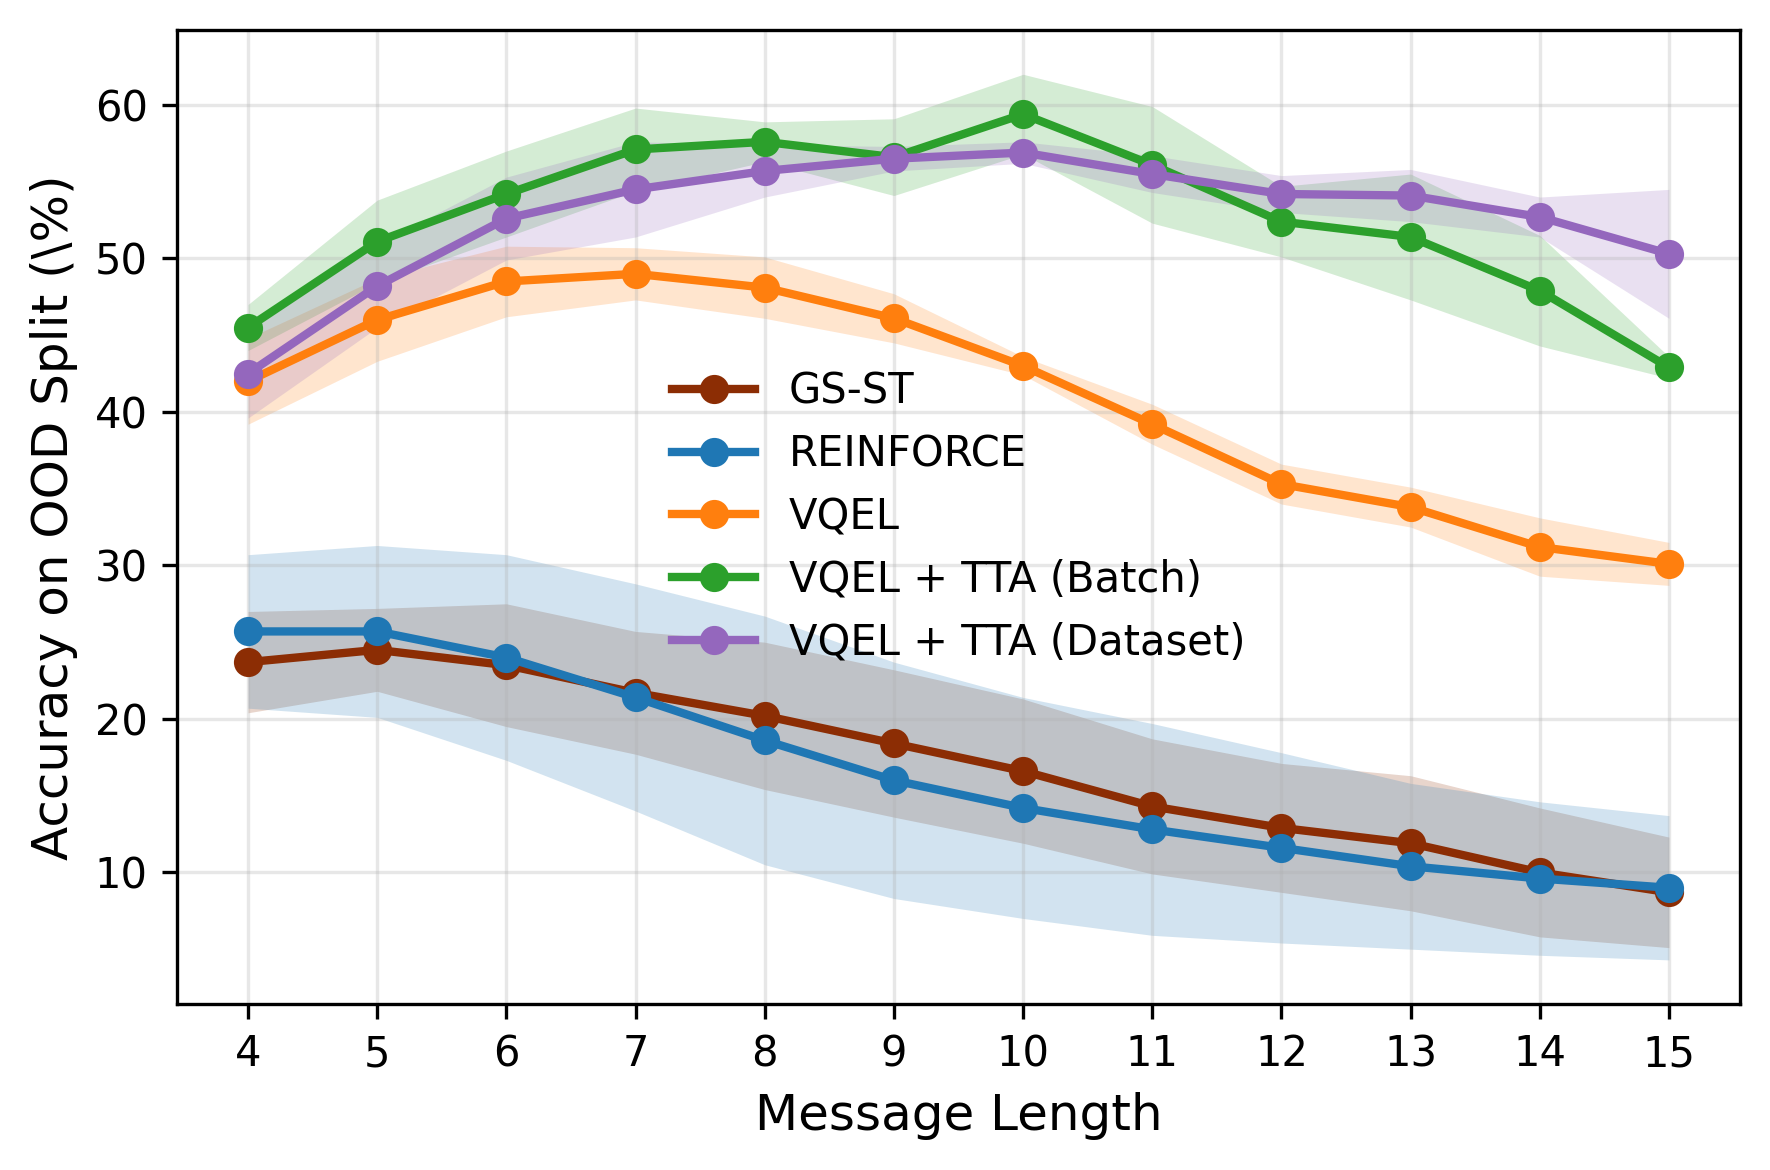

In [69]:
plot([mnist_gumbel, mnist_REINFORCE, mnist_VQ_NoTT, mnist_batch_adapt, mnist_dataset_adapt], name="mnist")

In [70]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, scaling], labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "Scaling"),name="mnist-scaling")

# ImageNet

## Gumbel - ID

In [71]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "None",
    "gumbel": True,
}, sort_by=["message_length", "seed"])
# res[gumbel_cols]

In [72]:
final = extract_maxes(res, max_col="mutual_play_accuracy")
final[gumbel_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase2_a,learning_rate_phase2_b,tau_0,mutual_play_accuracy,sampling_temperature,test_time_mode,path
0,1,True,imagenet,cosine,"[2, 3, 4]",-,1e-05,1e-01,72.6,1,-,20260214_1231_bs32_vocab10_repr2048_msg_len4_l...
1,2,True,imagenet,cosine,"[2, 3, 4]",-,1e-05,1e-01,73.6,1e-05,-,20260217_0025_bs32_vocab10_repr2048_msg_len4_l...
2,3,True,imagenet,cosine,"[2, 3, 4]",-,1e-05,1e-01,74.4,1e-05,-,20260217_0215_bs32_vocab10_repr2048_msg_len4_l...


In [73]:
mean = mean_and_std(final, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
mean

,dataset,message_length,mutual_play_accuracy
0,imagenet,"[2, 3, 4]",73.5 ± 0.9


## Gumbel - OOD

In [74]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "dialogued_checkpoint": "!None",
    "gumbel": True,
    "dataset_tt": "imagenet_same_class",
    "message_length": "[2, 3, 4]",
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [75]:
imagenet_gumbel = mean_and_std(res, metrics=["test_time_self_accuracy", "test_time_mutual_accuracy"] + metrics)
# imagenet_gumbel

## REINFORCE - ID

In [76]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "None",
    "gumbel": False,
}, sort_by=["message_length", "seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,85.9,20251231_1826_bs32_vocab10_repr2048_msg_len4_l...
1,2,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,84.6,20251231_1934_bs32_vocab10_repr2048_msg_len4_l...
2,3,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,86.9,20251231_1958_bs32_vocab10_repr2048_msg_len4_l...


In [77]:
mean_and_std(res)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,imagenet,"[2, 3, 4]",4,imagenet,-,0.0 ± 0.0,85.8 ± 1.2


## REINFORCE - OOD

In [78]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": True,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "!None",
    "gumbel": False,
    "dataset_tt": "imagenet_same_class",
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [79]:
final = extract_maxes(res)
# final[baseline_cols]

In [80]:
imagenet_REINFORCE = mean_and_std(final)
# imagenet_REINFORCE

## VQEL - ID

In [81]:
add_heading(2, "ImageNet")
add_heading(3, "Base Model")

res = filter_df({
    "dataset": "imagenet",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "imagenet",
    "message_length": "[2, 3, 4]"
}, sort_by=["vocab_size", "message_length","seed", "message_length_tt"])
res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,False,imagenet,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,88.4,89.1,20251231_2027_bs32_vocab10_repr2048_msg_len4_l...
1,2,False,imagenet,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,88.4,90.1,20251231_2046_bs32_vocab10_repr2048_msg_len4_l...
2,3,False,imagenet,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,88.1,89.8,20260101_1131_bs32_vocab10_repr2048_msg_len4_l...


In [82]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
# mean

## VQEL - OOD

In [83]:
add_heading(3, "Baseline")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": "-",
    "message_length": "[2, 3, 4]"
}, sort_by=["message_length", "message_length_tt", "seed"])
# res[baseline_cols]

In [84]:
imagenet_VQ_NoTT = mean_and_std(res)
# imagenet_VQ_NoTT

In [85]:
find_best_length_elbow(imagenet_VQ_NoTT)

[ 4  5  6  7  8  9 10 11 12 13 14 15]
[39.1 40.8 42.7 38.1 33.6 26.8 25.4 22.6 19.8 18.  15.9 15.2]


(np.int64(6), '43.9 ± 0.8')

## Scaling

In [86]:
add_heading(3, "Scaling")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": 'scaling'
}, sort_by=["message_length_tt", "sampling_temperature_tt", "best_of_n"])
# res[scaling_cols]

In [87]:
final = extract_maxes(res)
# final[scaling_cols]

In [88]:
scaling = mean_and_std(final)
# scaling

## Batch Adaptation

In [89]:
add_heading(3, "Adaptation")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": ["batch_adaptation"],
    "message_length": "[2, 3, 4]",
    "num_iterations": [50, 100, 200],
}, sort_by=["test_time_mode", "message_length_tt", "seed", "learning_rate_tt", "num_iterations"])
# res[adapt_cols]

In [90]:
final = extract_maxes_elbow(res, max_col= "test_time_mutual_accuracy")
# final[adapt_cols]

In [91]:
imagenet_batch_adapt = mean_and_std(final)
# imagenet_batch_adapt

In [92]:
find_best_length_elbow(imagenet_batch_adapt)

[ 4  5  6  7  8  9 10 11 12 13 14 15]
[72.3 75.9 77.1 74.6 72.5 65.9 63.1 60.8 59.  56.5 55.  54.7]


(np.int64(6), '71.1 ± 2.1')

## Dataset Adaptation

In [93]:
add_heading(3, "Adaptation")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": ["dataset_adaptation"],
    "message_length": "[2, 3, 4]",
    "num_iterations": [5, 10, 15, 20],
}, sort_by=["test_time_mode", "message_length_tt", "seed", "learning_rate_tt", "num_iterations"])
# res[adapt_cols]

In [94]:
final = extract_maxes_elbow(res)
# final[adapt_cols]

In [95]:
imagenet_dataset_adapt = mean_and_std(final)
imagenet_dataset_adapt

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,imagenet,"[2, 3, 4]",4,imagenet_same_class,dataset_adaptation,68.2 ± 2.0,64.9 ± 3.5
1,imagenet,"[2, 3, 4]",5,imagenet_same_class,dataset_adaptation,76.0 ± 1.6,69.4 ± 0.3
2,imagenet,"[2, 3, 4]",6,imagenet_same_class,dataset_adaptation,74.5 ± 1.4,67.5 ± 0.6
3,imagenet,"[2, 3, 4]",7,imagenet_same_class,dataset_adaptation,74.5 ± 1.7,65.2 ± 3.0
4,imagenet,"[2, 3, 4]",8,imagenet_same_class,dataset_adaptation,74.8 ± 0.8,61.6 ± 3.6
5,imagenet,"[2, 3, 4]",9,imagenet_same_class,dataset_adaptation,71.9 ± 1.5,55.4 ± 4.0
6,imagenet,"[2, 3, 4]",10,imagenet_same_class,dataset_adaptation,71.7 ± 1.7,54.3 ± 2.9
7,imagenet,"[2, 3, 4]",11,imagenet_same_class,dataset_adaptation,71.6 ± 1.5,53.1 ± 1.9
8,imagenet,"[2, 3, 4]",12,imagenet_same_class,dataset_adaptation,71.9 ± 3.3,51.8 ± 3.6
9,imagenet,"[2, 3, 4]",13,imagenet_same_class,dataset_adaptation,72.4 ± 0.9,48.8 ± 1.0


In [96]:
find_best_length_elbow(imagenet_dataset_adapt)

[ 4  5  6  7  8  9 10 11 12 13 14 15]
[68.2 76.  74.5 74.5 74.8 71.9 71.7 71.6 71.9 72.4 70.  69. ]


(np.int64(5), '69.4 ± 0.3')

## Plot

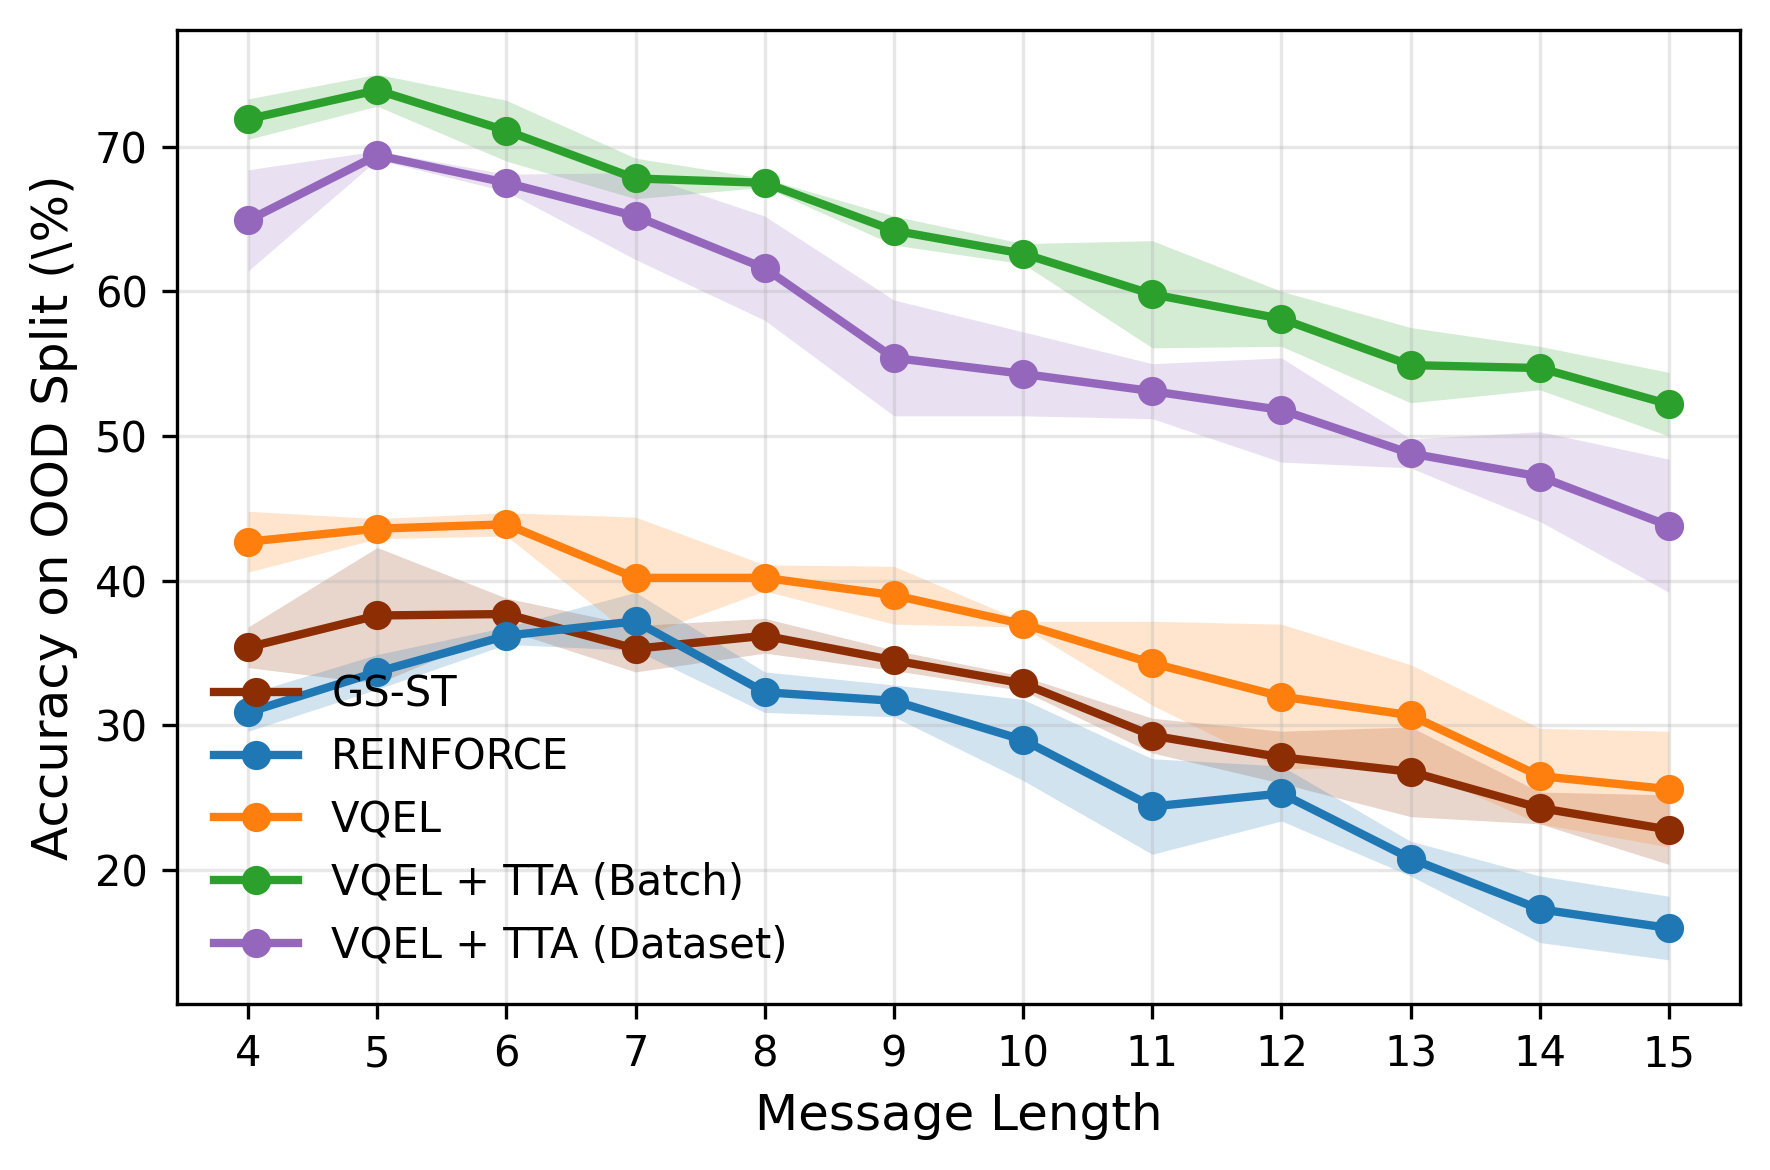

In [97]:
plot([imagenet_gumbel, imagenet_REINFORCE, imagenet_VQ_NoTT, imagenet_batch_adapt, imagenet_dataset_adapt], name="imagenet")

In [98]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, scaling], labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "Scaling"),name="imagenet-scaling")

# COCO

## Gumbel - ID

In [99]:
res = filter_df({
    "dataset": "coco",
    "baseline": True,
    "gumbel": True,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "None",
}, sort_by=["message_length", "seed"])
# res[gumbel_cols]

In [100]:
final = extract_maxes(res)
final[gumbel_cols]  

,seed,baseline,dataset,sim,message_length,learning_rate_phase2_a,learning_rate_phase2_b,tau_0,mutual_play_accuracy,sampling_temperature,test_time_mode,path
0,1,True,coco,cosine,"[2, 3, 4]",-,1e-05,1e-01,86.1,1e-05,-,20260609_1520_bs32_vocab10_repr768_msg_len4_ms...
1,2,True,coco,cosine,"[2, 3, 4]",-,1e-05,1e-01,85.5,1e-05,-,20260609_1539_bs32_vocab10_repr768_msg_len4_ms...
2,3,True,coco,cosine,"[2, 3, 4]",-,1e-04,0.2,86.5,1e-05,-,20260610_1218_bs32_vocab10_repr768_msg_len4_ms...


In [101]:
mean_and_std(final)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,coco,"[2, 3, 4]",4,coco,-,0.0 ± 0.0,86.0 ± 0.5


## Gumbel - OOD

In [102]:
res = filter_df({
    "dataset": "coco",
    "baseline": True,
    "gumbel": True,
    "dialogued_checkpoint": "!None",
    "dataset_tt": "coco_complex",
    "message_length": "[2, 3, 4]",
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [103]:
gumbel = mean_and_std(res)
# gumbel

## REINFORCE - ID

In [104]:
res = filter_df({
    "dataset": "coco",
    "baseline": True,
    "gumbel": False,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "None",
}, sort_by=["message_length", "seed"])
res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,coco,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,0,88.9,20260609_1605_bs32_vocab10_repr768_msg_len4_ms...
1,1,True,coco,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,85,20260609_1614_bs32_vocab10_repr768_msg_len4_ms...
2,2,True,coco,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,85.3,20260609_1631_bs32_vocab10_repr768_msg_len4_ms...
3,2,True,coco,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,0,88.4,20260609_1623_bs32_vocab10_repr768_msg_len4_ms...
4,3,True,coco,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,83.2,20260609_1649_bs32_vocab10_repr768_msg_len4_ms...
5,3,True,coco,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,0,89.1,20260609_1640_bs32_vocab10_repr768_msg_len4_ms...


In [105]:
final = extract_maxes(res)
final[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,coco,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,0,88.9,20260609_1605_bs32_vocab10_repr768_msg_len4_ms...
1,2,True,coco,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,0,88.4,20260609_1623_bs32_vocab10_repr768_msg_len4_ms...
2,3,True,coco,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,0,89.1,20260609_1640_bs32_vocab10_repr768_msg_len4_ms...


In [106]:
mean_and_std(final)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,coco,"[2, 3, 4]",4,coco,-,0.0 ± 0.0,88.8 ± 0.4


## REINFORCE - OOD

In [107]:
res = filter_df({
    "dataset": "coco",
    "dataset_tt": "coco_complex",
    "baseline": True,
    "gumbel": False,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "!None",
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [108]:
REINFORCE = mean_and_std(res)
# REINFORCE

## VQEL - ID

In [109]:
res = filter_df({
    "dataset": "coco",
    "dataset_tt": "coco",
    "baseline": False,
    "message_length": "[2, 3, 4]",
}, sort_by=["seed"])
res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,False,coco,cosine,"[2, 3, 4]",1e-03,-,1e-03,-,87.7,89.6,20260609_1409_bs32_vocab10_repr768_msg_len4_ms...
1,1,False,coco,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,86.7,89.9,20260609_1419_bs32_vocab10_repr768_msg_len4_ms...
2,2,False,coco,cosine,"[2, 3, 4]",1e-03,-,1e-03,-,87.5,88.8,20260609_1429_bs32_vocab10_repr768_msg_len4_ms...
3,2,False,coco,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,85.9,89.6,20260609_1440_bs32_vocab10_repr768_msg_len4_ms...
4,3,False,coco,cosine,"[2, 3, 4]",1e-03,-,1e-03,-,87.9,88.3,20260609_1450_bs32_vocab10_repr768_msg_len4_ms...
5,3,False,coco,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,83.8,88.2,20260609_1501_bs32_vocab10_repr768_msg_len4_ms...


In [110]:
final = extract_maxes(res)
final[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,False,coco,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,86.7,89.9,20260609_1419_bs32_vocab10_repr768_msg_len4_ms...
1,2,False,coco,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,85.9,89.6,20260609_1440_bs32_vocab10_repr768_msg_len4_ms...
2,3,False,coco,cosine,"[2, 3, 4]",1e-03,-,1e-03,-,87.9,88.3,20260609_1450_bs32_vocab10_repr768_msg_len4_ms...


In [111]:
mean_and_std(final)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,coco,"[2, 3, 4]",4,coco,-,86.8 ± 1.0,89.3 ± 0.9


## VQEL - OOD

In [112]:
res = filter_df({
    "dataset": "coco",
    "dataset_tt": "coco_complex",
    "baseline": False,
    "test_time_mode": "-",
    "message_length": "[2, 3, 4]",
}, sort_by=["message_length", "message_length_tt", "seed"])
# res[baseline_cols]

In [113]:
VQ_NoTT = mean_and_std(res)
VQ_NoTT

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,coco,"[2, 3, 4]",4,coco_complex,-,69.0 ± 2.1,49.7 ± 1.3
1,coco,"[2, 3, 4]",5,coco_complex,-,68.9 ± 2.0,50.7 ± 1.1
2,coco,"[2, 3, 4]",6,coco_complex,-,69.9 ± 1.5,51.3 ± 0.9
3,coco,"[2, 3, 4]",7,coco_complex,-,68.4 ± 2.0,50.3 ± 1.2
4,coco,"[2, 3, 4]",8,coco_complex,-,67.4 ± 1.8,50.4 ± 1.6
5,coco,"[2, 3, 4]",9,coco_complex,-,65.5 ± 1.9,49.8 ± 1.5
6,coco,"[2, 3, 4]",10,coco_complex,-,63.4 ± 2.5,48.9 ± 1.3
7,coco,"[2, 3, 4]",11,coco_complex,-,60.7 ± 2.3,48.3 ± 1.2
8,coco,"[2, 3, 4]",12,coco_complex,-,57.8 ± 3.2,47.7 ± 2.8
9,coco,"[2, 3, 4]",13,coco_complex,-,55.4 ± 3.0,47.1 ± 2.9


In [114]:
find_best_length_elbow(VQ_NoTT)

[ 4  5  6  7  8  9 10 11 12 13 14 15]
[69.  68.9 69.9 68.4 67.4 65.5 63.4 60.7 57.8 55.4 52.4 49.7]


(np.int64(8), '50.4 ± 1.6')

## Batch Adaptation

In [115]:
res = filter_df({
    "dataset": "coco",
    "dataset_tt": "coco_complex",
    "baseline": False,
    "test_time_mode": ["batch_adaptation"],
    "message_length": "[2, 3, 4]",
}, sort_by=["message_length_tt", "seed", "learning_rate_tt", "num_iterations"])
# res[adapt_cols]

In [116]:
final = extract_maxes_elbow(res)
# final[adapt_cols]

In [117]:
batch_adapt = mean_and_std(final)
batch_adapt

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,coco,"[2, 3, 4]",4,coco_complex,batch_adaptation,67.5 ± 0.2,63.6 ± 0.8
1,coco,"[2, 3, 4]",5,coco_complex,batch_adaptation,72.1 ± 0.7,65.7 ± 0.4
2,coco,"[2, 3, 4]",6,coco_complex,batch_adaptation,73.3 ± 1.4,66.5 ± 0.9
3,coco,"[2, 3, 4]",7,coco_complex,batch_adaptation,72.9 ± 1.7,66.2 ± 0.9
4,coco,"[2, 3, 4]",8,coco_complex,batch_adaptation,73.6 ± 1.4,64.5 ± 1.9
5,coco,"[2, 3, 4]",9,coco_complex,batch_adaptation,72.7 ± 1.6,64.0 ± 1.3
6,coco,"[2, 3, 4]",10,coco_complex,batch_adaptation,73.8 ± 2.8,62.8 ± 2.2
7,coco,"[2, 3, 4]",11,coco_complex,batch_adaptation,74.0 ± 2.5,62.1 ± 2.8
8,coco,"[2, 3, 4]",12,coco_complex,batch_adaptation,73.3 ± 3.1,60.8 ± 3.0
9,coco,"[2, 3, 4]",13,coco_complex,batch_adaptation,74.8 ± 0.9,59.5 ± 2.9


In [118]:
find_best_length_elbow(batch_adapt)

[ 4  5  6  7  8  9 10 11 12 13 14 15]
[67.5 72.1 73.3 72.9 73.6 72.7 73.8 74.  73.3 74.8 72.1 72.1]


(np.int64(6), '66.5 ± 0.9')

## Dataset Adaptation

In [119]:
res = filter_df({
    "dataset": "coco",
    "dataset_tt": "coco_complex",
    "baseline": False,
    "test_time_mode": ["dataset_adaptation"],
    "message_length": "[2, 3, 4]",
}, sort_by=["message_length_tt", "seed", "learning_rate_tt", "num_iterations"])
# res[adapt_cols]

In [120]:
final = extract_maxes_elbow(res)
# final[adapt_cols]

In [121]:
dataset_adapt = mean_and_std(final)
dataset_adapt

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,coco,"[2, 3, 4]",4,coco_complex,dataset_adaptation,57.7 ± 0.8,57.7 ± 0.3
1,coco,"[2, 3, 4]",5,coco_complex,dataset_adaptation,61.8 ± 1.7,59.6 ± 1.0
2,coco,"[2, 3, 4]",6,coco_complex,dataset_adaptation,63.1 ± 2.1,59.8 ± 1.0
3,coco,"[2, 3, 4]",7,coco_complex,dataset_adaptation,63.4 ± 3.2,58.3 ± 1.7
4,coco,"[2, 3, 4]",8,coco_complex,dataset_adaptation,64.0 ± 1.9,57.9 ± 2.2
5,coco,"[2, 3, 4]",9,coco_complex,dataset_adaptation,63.0 ± 3.4,56.6 ± 2.1
6,coco,"[2, 3, 4]",10,coco_complex,dataset_adaptation,61.4 ± 1.3,55.6 ± 2.5
7,coco,"[2, 3, 4]",11,coco_complex,dataset_adaptation,61.2 ± 0.6,55.0 ± 3.3
8,coco,"[2, 3, 4]",12,coco_complex,dataset_adaptation,62.2 ± 3.7,54.2 ± 3.3
9,coco,"[2, 3, 4]",13,coco_complex,dataset_adaptation,61.4 ± 2.8,53.9 ± 3.4


In [122]:
find_best_length_elbow(dataset_adapt)

[ 4  5  6  7  8  9 10 11 12 13 14 15]
[57.7 61.8 63.1 63.4 64.  63.  61.4 61.2 62.2 61.4 58.6 57.6]


(np.int64(8), '57.9 ± 2.2')

## Plot

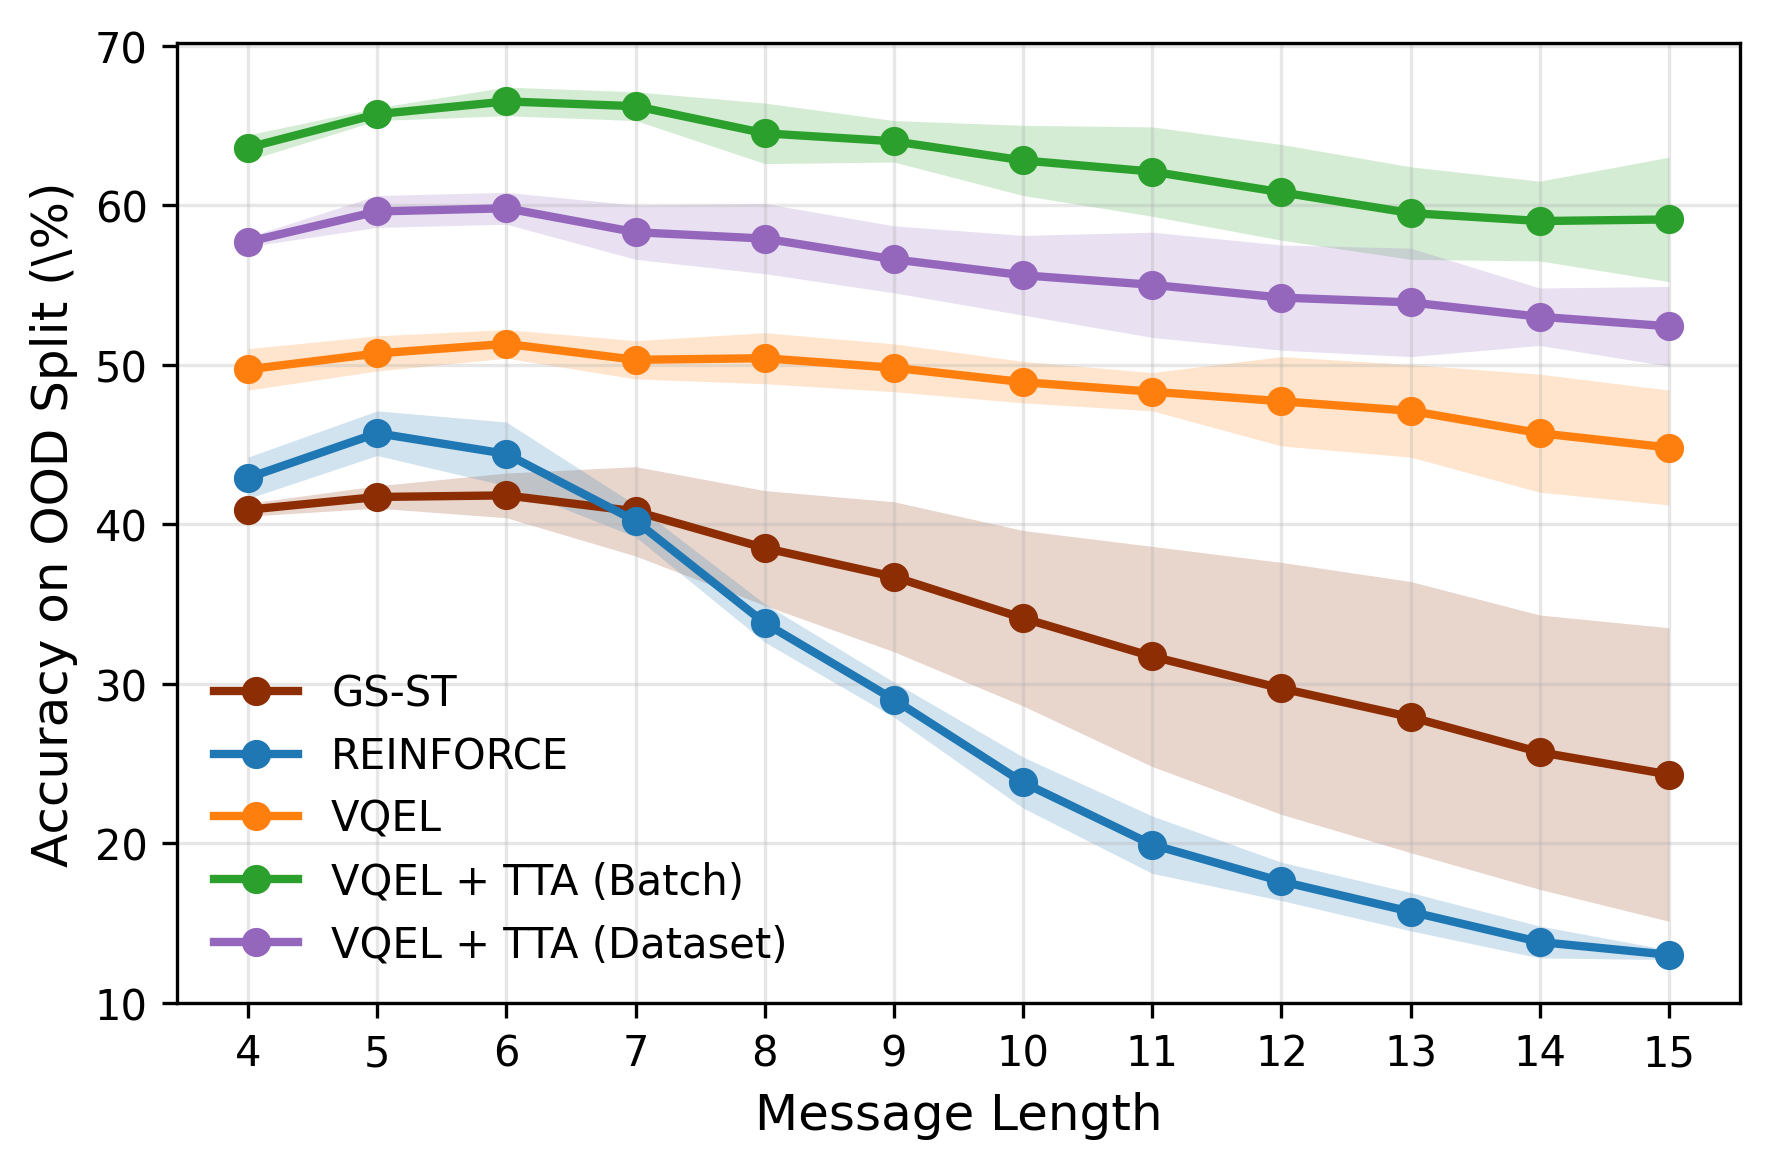

In [123]:
plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, dataset_adapt], name="coco")

# Batch Size

In [124]:
adapt_cols = [
    "seed",
    "baseline",
    "dataset",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "number_of_candidates",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

baseline_cols = [
    "seed",
    "baseline",
    "dataset",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "number_of_candidates",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

## ImageNet

In [125]:
number_of_candidates = [2, 4, 8, 16, 32, 64, 118]

### Gumbel - OOD

In [126]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "message_length_tt": 6,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "seed"])

# res[baseline_cols]

In [127]:
gumbel = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### REINFORCE - OOD

In [128]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "message_length_tt": 7,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "seed"])

# res[baseline_cols]

In [129]:
REINFORCE = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### VQEL - OOD

In [130]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": False,
    "test_time_mode": "-",
    "message_length_tt": 6,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])

# res[adapt_cols]

In [131]:
vqel = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])
# vqel

### Batch Adaptation

In [132]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": False,
    "test_time_mode": "batch_adaptation",
    "number_of_candidates": number_of_candidates,
    "message_length_tt": 5
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [133]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])
# final[adapt_cols]

In [134]:
batch_adapt = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Dataset Adaptation

In [135]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": False,
    "test_time_mode": "dataset_adaptation",
    "number_of_candidates": number_of_candidates,
    "message_length_tt": 5
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [136]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])
# final[adapt_cols]

In [137]:
dataset_adapt = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Plot

In [138]:
# plot([gumbel, REINFORCE, vqel, batch_adapt,dataset_adapt], labels=["GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "VQEL + TTA (Dataset)"], xlabel="Batch size", xcol="number_of_candidates", name="batch/imagenet_batch")

## MNIST

In [139]:
number_of_candidates = [2, 4, 8, 16, 32, 64, 128]

### Gumbel - OOD

In [140]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "message_length_tt": 4,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [141]:
gumbel = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### REINFORCE - OOD

In [142]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "message_length_tt": 5,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [143]:
REINFORCE = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### VQEL - OOD

In [144]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "-",
    "message_length_tt": 7,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])

# res[adapt_cols]

In [145]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])
# final[adapt_cols]

In [146]:
vqel = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Batch Adaptation

In [147]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "batch_adaptation",
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])

# res[adapt_cols]

In [148]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])
# final[adapt_cols]

In [149]:
batch_adapt = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Dataset Adaptation

In [150]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "dataset_adaptation",
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [151]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])

In [152]:
dataset_adapt = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Plot

In [153]:
# plot([gumbel, REINFORCE, vqel, batch_adapt, dataset_adapt], labels=["REINFORCE", "GS-ST", "VQEL" ,"VQEL + TTA (Batch)", "VQEL + TTA (Dataset)"], xlabel="Batch size", xcol="number_of_candidates", logscale=False, base=2, name="batch/mnist_batch")

# Learning Rate & Steps

In [154]:
num_iterations = list(range(1, 10)) + list(range(10, 100, 10)) + list(range(100, 1000, 100)) + [1000]

## MNIST

In [155]:
no_adapt = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": ["-"],
    "message_length_tt": 10,
    "learning_rate_tt": '-',
    "number_of_candidates": 100,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
# no_adapt[adapt_cols]

### Batch Adaptation

#### LR = 1e-4

In [156]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": ['1e-04'],
    "number_of_candidates": 100,
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [157]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [158]:
lr4 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### LR = 1e-5

In [159]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": ['1e-05'],
    "number_of_candidates": 100,
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [160]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [161]:
lr5 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr5

#### LR = 1e-6

In [162]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 10,
    "number_of_candidates": 100,
    "learning_rate_tt": ['1e-06'],
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [163]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")

In [164]:
lr6 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### Plot

In [165]:
# plot([lr4, lr5, lr6], labels=("LR = 1e-4", "LR = 1e-5", "LR = 1e-6"), xcol="num_iterations", xlabel="Steps", marker=None, logscale=True, xticks=range(0, 1010, 100), smooth_factor=0.5, name="steps/mnist_steps_batch")

### Dataset Adaptation

#### LR = 1e-4

In [166]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": '1e-04',
    "number_of_candidates": 100,
    "path": ">20260300",
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [167]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [168]:
lr4 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr4

#### LR = 1e-5

In [169]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": '1e-05',
    "number_of_candidates": 100,
    "path": ">20260300",
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [170]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [171]:
lr5 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### LR = 1e-6

In [172]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": '1e-06',
    "number_of_candidates": 100,
    "path": ">20260300",
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [173]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [174]:
lr6 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### Plot

In [175]:
# plot([lr4, lr5, lr6], labels=("LR = 1e-4", "LR = 1e-5", "LR = 1e-6"), xcol="num_iterations", xlabel="Steps", marker=None, logscale=False, smooth_factor=0.5, xticks=range(0, 201, 25), name="steps/mnist_steps_dataset")

## ImageNet

In [176]:
no_adapt = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": ["-"],
    "message_length_tt": 5,
    "learning_rate_tt": ['-'],
    "message_length": '[2, 3, 4]',
}, sort_by=["message_length_tt", "seed", "num_iterations"])
# no_adapt[adapt_cols]

### Batch Adaptation

#### LR = 1e-4

In [177]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": ['1e-04'],
    "message_length": '[2, 3, 4]',
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [178]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [179]:
lr4 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### LR = 1e-5

In [180]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": '1e-05',
    "message_length": '[2, 3, 4]',
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [181]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")


In [182]:
lr5 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr5


#### LR = 1e-6

In [183]:
res = filter_df({
    "dataset": "imagenet",
    "VQEL": True,
    "dataset_tt": "imagenet_same_class",
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": '1e-06',
    "message_length": '[2, 3, 4]',
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [184]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")

In [185]:
lr6 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr6

#### Plot

In [186]:
# plot([lr4, lr5, lr6], labels=("LR = 1e-4", "LR = 1e-5", "LR = 1e-6"), xcol="num_iterations", xlabel="Steps", marker=None, logscale=True, xticks=range(0, 1010, 100), smooth_factor=0.5, name="steps/imagenet_steps_batch")

### Dataset Adaptation

#### LR = 1e-4

In [187]:
res = filter_df({
    "dataset": "imagenet",
    "VQEL": True,
    "dataset_tt": "imagenet_same_class",
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": ['1e-04'],
    "message_length": '[2, 3, 4]',
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [188]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [189]:
lr4 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr4

#### LR = 1e-5

In [190]:
res = filter_df({
    "dataset": "imagenet",
    "VQEL": True,
    "dataset_tt": "imagenet_same_class",
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": ['1e-05'],
    "message_length": '[2, 3, 4]',
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [191]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [192]:
lr5 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr5

#### LR = 1e-6

In [193]:
res = filter_df({
    "dataset": "imagenet",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 5,
    "dataset_tt": "imagenet_same_class",
    "learning_rate_tt": ['1e-06'],
    "message_length": '[2, 3, 4]',
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])

# res[adapt_cols]

In [194]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")

In [195]:
lr6 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr6

#### Plot

In [196]:
# plot([lr4, lr5, lr6], labels=("LR = 1e-4", "LR = 1e-5", "LR = 1e-6"), xcol="num_iterations", xlabel="Steps", marker=None, logscale=False, smooth_factor=0.6, xticks=range(0, 201, 25), name="steps/imagenet_steps_dataset")

# Computation Costs

In [197]:
mask = df["inference_time"] != "None"
df.loc[mask, "inference_time"] = df.loc[mask, "inference_time"] / (1000) # S

mask = df["peak_memory"] != "None"
df.loc[mask, "peak_memory"] = df.loc[mask, "peak_memory"] / (1024 ** 3) # GB

mask = df["flops"] != "None"
df.loc[mask, "flops"] = df.loc[mask, "flops"] / (10 ** 9) # GFLOPS

In [198]:
computation_metrics = [
    "inference_time",
    "peak_memory",
    "flops",
]

## MNIST

### Gumbel

In [199]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "gumbel": True,
    "message_length_tt": 10,
    "flops": "!None",
}, sort_by=["message_length_tt", "seed", "num_iterations"])

res[baseline_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,1,True,mnist1,"[3, 4]",10,mnist2,-,100,0,22.1,20260222_1711_bs32_vocab10_repr192_msg_len10_l...,0.2736895752,0.08895587921,4.1236608
1,2,True,mnist1,"[3, 4]",10,mnist2,-,100,0,13.6,20260222_1713_bs32_vocab10_repr192_msg_len10_l...,0.2499892731,0.08895587921,4.1236608
2,3,True,mnist1,"[3, 4]",10,mnist2,-,100,0,14.2,20260222_1715_bs32_vocab10_repr192_msg_len10_l...,0.2404720001,0.08895587921,4.1236608


In [200]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,mnist1,"[3, 4]",10,mnist2,-,16.6 ± 4.7,0.3 ± 0.0,0.1 ± 0.0,4.1 ± 0.0


### REINFORCE

In [201]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "gumbel": False,
    "message_length_tt": 10,
    "flops": "!None",
})

res[baseline_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,2,True,mnist1,"[3, 4]",10,mnist2,-,100,0,7.3,20251230_2039_bs32_vocab10_repr192_msg_len10_l...,0.2429607086,0.08895301819,4.1236608
1,1,True,mnist1,"[3, 4]",10,mnist2,-,100,0,21.6,20251230_2037_bs32_vocab10_repr192_msg_len10_l...,0.2439423981,0.08895301819,4.1236608
2,3,True,mnist1,"[3, 4]",10,mnist2,-,100,0,13.6,20251230_2040_bs32_vocab10_repr192_msg_len10_l...,0.2439713593,0.08895301819,4.1236608


In [202]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,mnist1,"[3, 4]",10,mnist2,-,14.2 ± 7.2,0.2 ± 0.0,0.1 ± 0.0,4.1 ± 0.0


### VQEL

In [203]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "gumbel": False,
    "message_length_tt": 10,
    "test_time_mode": "-",
    "flops": "!None",
})

res[baseline_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,3,False,mnist1,"[3, 4]",10,mnist2,-,100,44.4,42.4,20260316_1906_bs32_vocab10_repr192_msg_len10_m...,0.2891046143,0.08967065811,4.12608
1,2,False,mnist1,"[3, 4]",10,mnist2,-,100,50.9,43,20251229_0028_bs32_vocab10_repr192_msg_len10_l...,0.2924754333,0.08967065811,4.12608
2,1,False,mnist1,"[3, 4]",10,mnist2,-,100,47.5,43.5,20260316_1906_bs32_vocab10_repr192_msg_len10_m...,0.299907135,0.08967065811,4.12608


In [204]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,mnist1,"[3, 4]",10,mnist2,-,43.0 ± 0.6,0.3 ± 0.0,0.1 ± 0.0,4.1 ± 0.0


### Batch Adaptation

In [205]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "gumbel": False,
    "message_length_tt": 10,
    "test_time_mode": "batch_adaptation",
    "flops": "!None",
})

res[adapt_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,2,False,mnist1,"[3, 4]",10,mnist2,batch_adaptation,100,1e-04,100,66.5,57.6,20260525_1940_bs32_vocab10_repr192_msg_len10_m...,83.01031472,0.6367726326,17.59296
1,3,False,mnist1,"[3, 4]",10,mnist2,batch_adaptation,100,1e-04,100,63.2,56.2,20260525_1942_bs32_vocab10_repr192_msg_len10_m...,83.6767073,0.6367726326,17.59296
2,1,False,mnist1,"[3, 4]",10,mnist2,batch_adaptation,100,1e-04,100,67.7,58.4,20260525_1939_bs32_vocab10_repr192_msg_len10_m...,96.25747958,0.6367726326,17.59296


In [206]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,mnist1,"[3, 4]",10,mnist2,batch_adaptation,57.4 ± 1.1,87.6 ± 7.5,0.6 ± 0.0,17.6 ± 0.0


### Dataset Adaptation

In [207]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "gumbel": False,
    "message_length_tt": 10,
    "test_time_mode": "dataset_adaptation",
    "flops": "!None",
})

res[adapt_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,2,False,mnist1,"[3, 4]",10,mnist2,dataset_adaptation,100,1e-04,10,56.8,56.1,20260525_1822_bs32_vocab10_repr192_msg_len10_m...,10.09257617,0.3433170319,5.472768
1,1,False,mnist1,"[3, 4]",10,mnist2,dataset_adaptation,100,1e-04,10,55.2,55.7,20260525_1822_bs32_vocab10_repr192_msg_len10_m...,9.698804687,0.3433170319,5.472768
2,3,False,mnist1,"[3, 4]",10,mnist2,dataset_adaptation,100,1e-04,10,51.7,54.7,20260525_1823_bs32_vocab10_repr192_msg_len10_m...,9.530878906,0.3433170319,5.472768


In [208]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,mnist1,"[3, 4]",10,mnist2,dataset_adaptation,55.5 ± 0.7,9.8 ± 0.3,0.3 ± 0.0,5.5 ± 0.0


## ImageNet

### Gumbel

In [209]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "gumbel": True,
    "message_length_tt": 5,
    "flops": "!None",
}, sort_by=["message_length_tt", "seed", "num_iterations"])

res[baseline_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,1,True,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,0,40.4,20260222_1717_bs32_vocab10_repr2048_msg_len5_l...,0.3862895508,0.5644178391,0.809238528
1,2,True,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,0,40.1,20260222_1720_bs32_vocab10_repr2048_msg_len5_l...,0.2555688019,0.5644178391,0.809238528
2,3,True,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,0,32.2,20260222_1724_bs32_vocab10_repr2048_msg_len5_l...,0.3410332031,0.5644178391,0.809238528


In [210]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,37.6 ± 4.7,0.3 ± 0.1,0.6 ± 0.0,0.8 ± 0.0


### REINFORCE

In [211]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "gumbel": False,
    "message_length_tt": 5,
    "flops": "!None",
}, sort_by=["message_length_tt", "seed", "num_iterations"])

res[baseline_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,1,True,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,0,32.4,20260101_1821_bs32_vocab10_repr2048_msg_len5_l...,0.2550014038,0.5644016266,0.809238528
1,2,True,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,0,34.7,20260101_1824_bs32_vocab10_repr2048_msg_len5_l...,0.2555042877,0.5644016266,0.809238528
2,3,True,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,0,33.9,20260101_1826_bs32_vocab10_repr2048_msg_len5_l...,0.4746801453,0.5644016266,0.809238528


In [212]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,33.7 ± 1.2,0.3 ± 0.1,0.6 ± 0.0,0.8 ± 0.0


### VQEL

In [213]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "gumbel": False,
    "test_time_mode": "-",
    "message_length_tt": 5,
    "flops": "!None",
})

res[baseline_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,2,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,41.2,43.2,20260101_1816_bs32_vocab10_repr2048_msg_len5_l...,0.316145813,0.5656247139,0.812909804
1,1,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,41,44.4,20260101_1813_bs32_vocab10_repr2048_msg_len5_l...,0.3081534424,0.5656247139,0.812909804
2,3,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,40.3,43.3,20260101_1818_bs32_vocab10_repr2048_msg_len5_l...,0.3116493835,0.5656247139,0.812909804


In [214]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,43.6 ± 0.7,0.3 ± 0.0,0.6 ± 0.0,0.8 ± 0.0


### Batch Adaptation

In [215]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "gumbel": False,
    "message_length_tt": 5,
    "test_time_mode": "batch_adaptation",
    "flops": "!None",
})

res[adapt_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,2,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,batch_adaptation,32,1e-04,10,71.1,69.1,20260525_1918_bs32_vocab10_repr2048_msg_len5_m...,12.15374523,1.81649828,25.18054312
1,3,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,batch_adaptation,32,1e-04,10,71.3,68.1,20260525_1919_bs32_vocab10_repr2048_msg_len5_m...,12.04735528,1.81649828,25.18054312
2,1,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,batch_adaptation,32,1e-04,10,72.4,69.6,20260525_1918_bs32_vocab10_repr2048_msg_len5_m...,12.14755176,1.81649828,25.18054312


In [216]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,imagenet,"[2, 3, 4]",5,imagenet_same_class,batch_adaptation,68.9 ± 0.8,12.1 ± 0.1,1.8 ± 0.0,25.2 ± 0.0


### Dataset Adaptation

In [217]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "gumbel": False,
    "message_length_tt": 5,
    "test_time_mode": "dataset_adaptation",
    "flops": "!None",
})

res[adapt_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,1,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,dataset_adaptation,32,1e-04,10,74.4,69.6,20260525_1903_bs32_vocab10_repr2048_msg_len5_m...,12.11384668,1.201653957,25.18054312
1,2,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,dataset_adaptation,32,1e-04,10,77.6,69.1,20260525_1904_bs32_vocab10_repr2048_msg_len5_m...,12.02887598,1.201653957,25.18054312
2,3,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,dataset_adaptation,32,1e-04,10,76.1,69.6,20260525_1904_bs32_vocab10_repr2048_msg_len5_m...,12.31262109,1.201653957,25.18054312


In [218]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,imagenet,"[2, 3, 4]",5,imagenet_same_class,dataset_adaptation,69.4 ± 0.3,12.2 ± 0.1,1.2 ± 0.0,25.2 ± 0.0


# MPs Alignment

In [219]:
alignment_metrics = [
    "mp_similarity",
    "mp_similarity_baseline_mean",
    "mp_similarity_baseline_std",
    "mp_similarity_p_value"
]

## Shape

In [220]:
res = filter_df({
    "dataset": "shape1",
    "baseline": False,
    "gumbel": False,
    "mp_similarity": "!None",
})

res[baseline_cols + alignment_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,mp_similarity,mp_similarity_baseline_mean,mp_similarity_baseline_std,mp_similarity_p_value


In [221]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + alignment_metrics, precision=3)

KeyError: 'dataset'

## MNIST

In [ ]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "gumbel": False,
    "mp_similarity": "!None",
})

res[baseline_cols + alignment_metrics]

In [ ]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + alignment_metrics, precision=3)

## ImageNet

In [ ]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "gumbel": False,
    "mp_similarity": "!None",
})

res[baseline_cols + alignment_metrics]

In [ ]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + alignment_metrics, precision=3)

## COCO

In [ ]:
res = filter_df({
    "dataset": "coco",
    "baseline": False,
    "gumbel": False,
    "mp_similarity": "!None",
})

res[baseline_cols + alignment_metrics]

In [ ]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + alignment_metrics, precision=3)

# Random Length Trick

## MNIST

### Gumbel

In [ ]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "dataset_tt": "mnist1",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "seed"])

# res[gumbel_cols]

In [ ]:
mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])

### Gumbel - OOD

In [ ]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "dataset_tt": "mnist2",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [ ]:
gumbel = mean_and_std(res)
# gumbel

In [ ]:
gumbel3 = gumbel.iloc[:13].reset_index(drop=True)
gumbel4 = gumbel.iloc[13:].reset_index(drop=True)

### REINFORCE - ID

In [ ]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "dataset_tt": "mnist1",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "seed"])

# res[backbone_cols]

In [ ]:
mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])

### REINFORCE - OOD

In [ ]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "dataset_tt": "mnist2",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [ ]:
REINFORCE = mean_and_std(res)
# REINFORCE

In [ ]:
REINFORCE3 = REINFORCE.iloc[:13].reset_index(drop=True)
REINFORCE4 = REINFORCE.iloc[13:].reset_index(drop=True)

### VQEL - ID

In [ ]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "mnist1",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "seed"])

res[backbone_cols]

In [ ]:
mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])

### VQEL - OOD

In [ ]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "mnist2",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [ ]:
VQ_NoTT = mean_and_std(res)
# VQ_NoTT

In [ ]:
VQ_NoTT3 = VQ_NoTT.iloc[:13].reset_index(drop=True)
VQ_NoTT4 = VQ_NoTT.iloc[13:].reset_index(drop=True)

### Batch Adaptation

In [ ]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "test_time_mode": "batch_adaptation",
    "dataset_tt": "mnist2",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

res[adapt_cols]

In [ ]:
batch_adapt = mean_and_std(res)
batch_adapt

In [ ]:
batch_adapt3 = batch_adapt.iloc[:13].reset_index(drop=True)
batch_adapt4 = batch_adapt.iloc[13:].reset_index(drop=True)

### Dataset Adaptation

In [ ]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "test_time_mode": "dataset_adaptation",
    "dataset_tt": "mnist2",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

res[adapt_cols]

In [ ]:
dataset_adapt = mean_and_std(res)
dataset_adapt

In [ ]:
dataset_adapt3 = dataset_adapt.iloc[:13].reset_index(drop=True)
dataset_adapt4 = dataset_adapt.iloc[13:].reset_index(drop=True)

### Plot

In [ ]:
plot([gumbel3, REINFORCE3, VQ_NoTT3, batch_adapt3, dataset_adapt3], name="rlt/mnist_without_rlt_l3")

In [ ]:
plot([gumbel4, REINFORCE4, VQ_NoTT4, batch_adapt4, dataset_adapt4], name="rlt/mnist_without_rlt_l4")

## ImageNet

### Gumbel - ID

In [ ]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "dataset_tt": "imagenet",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "seed"])

res[gumbel_cols]

In [ ]:
mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])

### Gumbel - OOD

In [ ]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "dataset_tt": "imagenet_same_class",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [ ]:
gumbel = mean_and_std(res)
# gumbel

In [ ]:
gumbel3 = gumbel.iloc[:13].reset_index(drop=True)
gumbel4 = gumbel.iloc[13:].reset_index(drop=True)

### REINFORCE - ID

In [ ]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "dataset_tt": "imagenet",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "seed"])

res[backbone_cols]

In [ ]:
mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])

### REINFORCE - OOD

In [ ]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "dataset_tt": "imagenet_same_class",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [ ]:
REINFORCE = mean_and_std(res)
# REINFORCE

In [ ]:
REINFORCE3 = REINFORCE.iloc[:13].reset_index(drop=True)
REINFORCE4 = REINFORCE.iloc[13:].reset_index(drop=True)

### VQEL - ID

In [ ]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "imagenet",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "seed"])

res[backbone_cols]

In [ ]:
mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])

### VQEL - OOD

In [ ]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "imagenet_same_class",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [ ]:
VQ_NoTT = mean_and_std(res)
VQ_NoTT

In [ ]:
VQ_NoTT3 = VQ_NoTT.iloc[:13].reset_index(drop=True)
VQ_NoTT4 = VQ_NoTT.iloc[13:].reset_index(drop=True)

### Batch Adaptation

In [ ]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "test_time_mode": "batch_adaptation",
    "dataset_tt": "imagenet_same_class",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

res[adapt_cols]

In [ ]:
batch_adapt = mean_and_std(res)
# batch_adapt

In [ ]:
batch_adapt3 = batch_adapt.iloc[:13].reset_index(drop=True)
batch_adapt4 = batch_adapt.iloc[13:].reset_index(drop=True)

### Dataset Adaptation

In [ ]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "test_time_mode": "dataset_adaptation",
    "dataset_tt": "imagenet_same_class",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[adapt_cols]

In [ ]:
dataset_adapt = mean_and_std(res)
# dataset_adapt

In [ ]:
dataset_adapt3 = dataset_adapt.iloc[:13].reset_index(drop=True)
dataset_adapt4 = dataset_adapt.iloc[13:].reset_index(drop=True)

### Plot

In [ ]:
# plot([gumbel3, REINFORCE3, VQ_NoTT3, batch_adapt3, dataset_adapt3], name="rlt/imagenet_without_rlt_l3")

In [ ]:
# plot([gumbel4, REINFORCE4, VQ_NoTT4, batch_adapt4, dataset_adapt4], name="rlt/imagenet_without_rlt_l4")

# Full sender Adaptation

## MNIST

### Batch Adaptation

In [ ]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "test_time_mode": "full_sender_batch_adaptation",
    "dataset_tt": "mnist2",
}, sort_by=["message_length_tt", "seed"])

# res[adapt_cols]

In [ ]:
final = extract_maxes(res)
# final[adapt_cols]

In [ ]:
batch_adapt = mean_and_std(final)
# batch_adapt

### Dataset Adaptation

In [ ]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "test_time_mode": "full_sender_dataset_adaptation",
    "dataset_tt": "mnist2",
}, sort_by=["message_length_tt", "seed"])

# res[adapt_cols]

In [ ]:
dataset_adapt = mean_and_std(res)
# dataset_adapt

### Plot

In [ ]:
# plot([mnist_gumbel, mnist_REINFORCE, mnist_VQ_NoTT, batch_adapt, mnist_batch_adapt], 
#       labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Full)", "VQEL + TTA (MG)"),
#       name="full_adaptation/mnist_batch")

In [ ]:
# plot([mnist_gumbel, mnist_REINFORCE, mnist_VQ_NoTT, dataset_adapt, mnist_dataset_adapt], 
#       labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Full)", "VQEL + TTA (MG)"),
#       name="full_adaptation/mnist_dataset")

## ImageNet

### Batch Adaptation

In [ ]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "test_time_mode": "full_sender_batch_adaptation",
    "dataset_tt": "imagenet_same_class",
}, sort_by=["message_length_tt", "seed"])

# res[adapt_cols]

In [ ]:
final = extract_maxes(res)
# final[adapt_cols]

In [ ]:
batch_adapt = mean_and_std(final)
# batch_adapt

### Dataset Adaptation

In [ ]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "test_time_mode": "full_sender_dataset_adaptation",
    "dataset_tt": "imagenet_same_class",
}, sort_by=["message_length_tt", "seed"])

# res[adapt_cols]

In [ ]:
dataset_adapt = mean_and_std(res)
dataset_adapt

### Plot

In [ ]:
# plot([imagenet_gumbel, imagenet_REINFORCE, imagenet_VQ_NoTT, batch_adapt, imagenet_batch_adapt], 
#       labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Full)", "VQEL + TTA (MG)"),
#       name="full_adaptation/imagenet_batch")

In [ ]:
# plot([imagenet_gumbel, imagenet_REINFORCE, imagenet_VQ_NoTT, dataset_adapt, imagenet_dataset_adapt], 
#       labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Full)", "VQEL + TTA (MG)"),
#       name="full_adaptation/imagenet_dataset")